# Playing Cards Image Classifier — 97.74% with Fine-tuned ResNet-18 + SVM

This notebook documents the full experimental journey toward a **53-class playing cards classifier** (52 standard cards + Joker).  
Rather than just showing the final result, we walk through **what we tried, why it failed or worked**, and build up to the best solution step by step.

**Dataset:** [Cards Image Dataset Classification](https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification/data)

| Split | Samples | Samples/class |
|-------|---------|---------------|
| Train | 7,624   | ~144          |
| Val   | 265     | 5             |
| Test  | 265     | 5             |

**Key challenge:** Only ~144 training images per class — a small dataset where overfitting is a real risk.

**Best result:** Fine-tuned ResNet-18 backbone → SVM classifier → **97.74% test accuracy**

## 1. Setup & Imports

In [1]:
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

import torch

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 0
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
# ─────────────────────────────────────────────────────────────────────────────

# Style
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch {torch.__version__} | device: {device} | seed: {SEED}')

PyTorch 2.10.0+cu128 | device: cuda | seed: 0


## 2. Dataset

The dataset ships with a `cards.csv` manifest. Each row has the image filepath, label name, class index, and a `data set` column (`train`/`valid`/`test`). Images are 224×224 RGB JPEGs pre-organized into class folders.

### Data loading code

In [2]:
# ── Dataset & transforms (reference code — not executed during training here) ────────────────
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CardsDataset(Dataset):
    def __init__(self, df, data_dir: str, transform=None):
        self.df = df.reset_index(drop=True)
        self.data_dir = data_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(os.path.join(self.data_dir, row['filepaths'])).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, int(row['class index'])


# Training transforms: mild augmentation to reduce overfitting on small dataset
train_tf = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),  # ImageNet stats
])

# Val/test: only normalization
val_tf = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

print('CardsDataset and transforms defined.')
print('Augmentation strategy: RandomHorizontalFlip + RandomRotation(10) for train only.')
print('Kept minimal — too much augmentation on card images (strict visual structure) can hurt performance.')

CardsDataset and transforms defined.
Augmentation strategy: RandomHorizontalFlip + RandomRotation(10) for train only.
Kept minimal — too much augmentation on card images (strict visual structure) can hurt performance.


## 3. Experiment Overview

We ran 8 distinct experiments. Here are the final test results:

| Model | Test Accuracy | Test F1 |
|---|---|---|
| CustomCNN (from scratch) | 70.57% | 70.12% |
| ResNet-18 frozen + MLP head | 52.83% | 51.36% |
| ResNet-18 fine-tune (lr=1e-2) | 90.94% | 90.77% |
| ResNet-18 fine-tune (lr=1e-3) | 95.85% | 95.74% |
| ResNet-18 fine-tune (lr=5e-4) | 96.98% | 96.95% |
| **ResNet-18 fine-tune (lr=1e-4)** | **97.36%** | **97.33%** |
| SVM on ImageNet features | 46.04% | 45.74% |
| **SVM on fine-tuned features** | **97.74%** | **97.74%** |

Two surprising findings:
1. A frozen pretrained backbone performed *worse* than a CNN trained from scratch.
2. An SVM on top of fine-tuned features outperformed the end-to-end neural network.

The rest of this notebook explains **why**.

## 4. Baseline: CNN from Scratch

We start with a simple 3-block CNN trained entirely from random initialization on the 7,624 training images.

### Architecture

In [3]:
import torch.nn as nn

class CustomCNN(nn.Module):
    """
    3-block CNN trained from scratch.
    Block 1: Conv(3→32)  + BN + ReLU + MaxPool  → 112×112
    Block 2: Conv(32→64) + BN + ReLU + MaxPool  →  56×56
    Block 3: Conv(64→128)+ BN + ReLU + MaxPool  →  28×28
    Classifier: Linear(128×28×28 → 53)
    """
    def __init__(self, num_classes: int = 53):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
        )
        self.classifier = nn.Linear(128 * 28 * 28, num_classes)

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x.view(x.size(0), -1))


cnn = CustomCNN()
total_params = sum(p.numel() for p in cnn.parameters())
print(f'CustomCNN total parameters: {total_params:,}')

CustomCNN total parameters: 5,412,405


### Training curve — CustomCNN (30 epochs)

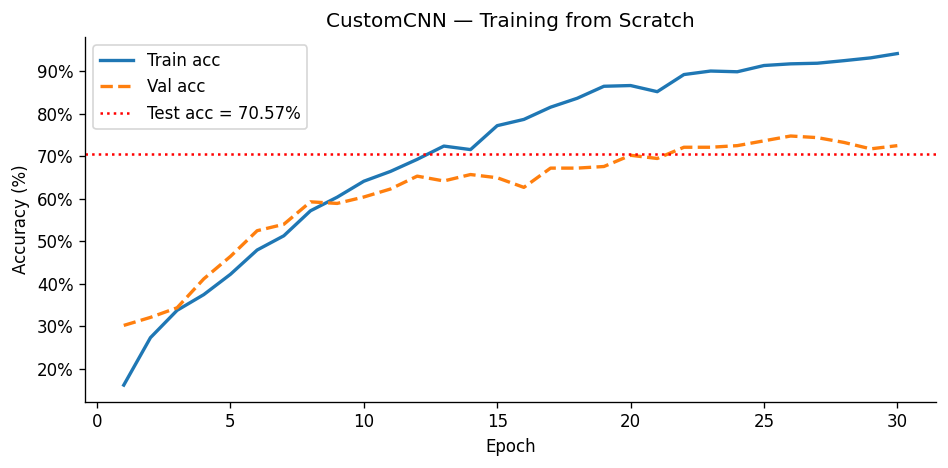


Test accuracy: 70.57% | Test F1: 70.12%

Observation: train acc >> val acc from epoch ~13 → classic overfitting.
With only ~144 images/class, the model memorizes the training set.


In [4]:
# Training history (hardcoded from runs/custom_cnn_lr0.001_bs64_ep30_*/results.csv)
cnn_epochs     = list(range(1, 31))
cnn_train_acc  = [0.161595,0.273085,0.337356,0.374344,0.422088,0.479145,0.512592,0.571354,
                  0.603358,0.640871,0.663956,0.692288,0.723505,0.715241,0.771511,0.786201,
                  0.814927,0.835913,0.864113,0.865818,0.85139,0.891658,0.899921,0.898216,
                  0.912907,0.916842,0.918284,0.924318,0.930876,0.940976]
cnn_val_acc    = [0.301887,0.320755,0.343396,0.411321,0.464151,0.524528,0.539623,0.592453,
                  0.588679,0.603774,0.622642,0.65283,0.641509,0.656604,0.649057,0.626415,
                  0.671698,0.671698,0.675472,0.701887,0.69434,0.720755,0.720755,0.724528,
                  0.735849,0.74717,0.743396,0.732075,0.716981,0.724528]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(cnn_epochs, [v * 100 for v in cnn_train_acc], label='Train acc', lw=2)
ax.plot(cnn_epochs, [v * 100 for v in cnn_val_acc],   label='Val acc',   lw=2, ls='--')
ax.axhline(70.57, color='red', ls=':', lw=1.5, label='Test acc = 70.57%')
ax.set_xlabel('Epoch')
ax.set_ylabel('Accuracy (%)')
ax.set_title('CustomCNN — Training from Scratch')
ax.legend()
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

print('\nTest accuracy: 70.57% | Test F1: 70.12%')
print()
print('Observation: train acc >> val acc from epoch ~13 → classic overfitting.')
print('With only ~144 images/class, the model memorizes the training set.')

**Result: 70.57% test accuracy.**

Not bad for a simple CNN trained from random weights on a small dataset. The gap between train accuracy (~94%) and val/test accuracy (~70%) reveals **overfitting** — the network memorizes training images rather than learning generalizable card features.

Can transfer learning help?

## 5. Transfer Learning — Frozen Backbone

The obvious next step: use a pretrained ResNet-18 (trained on ImageNet) as a fixed feature extractor, and only train a classification head on top.

### Architecture

In [5]:
import torchvision.models as models

class ResNet18MLP(nn.Module):
    """Frozen ResNet-18 backbone + trainable MLP head."""
    def __init__(self, num_classes: int = 53):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Freeze ALL backbone parameters — nothing is updated during training
        for param in backbone.parameters():
            param.requires_grad = False

        # Replace fc layer with a small MLP
        backbone.fc = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
        self.model = backbone

    def forward(self, x):
        return self.model(x)


mlp_model = ResNet18MLP()
trainable = sum(p.numel() for p in mlp_model.parameters() if p.requires_grad)
frozen    = sum(p.numel() for p in mlp_model.parameters() if not p.requires_grad)
print(f'Trainable parameters: {trainable:,}')
print(f'Frozen parameters:    {frozen:,}')
print(f'Ratio trained: {trainable/(trainable+frozen)*100:.1f}%')

Trainable parameters: 144,949
Frozen parameters:    11,176,512
Ratio trained: 1.3%


### Result: **52.83%** — worse than the CNN from scratch!

This is a surprising but instructive failure. Why?

**ImageNet features don't transfer to cards.**

ImageNet contains 1,000 classes — mostly animals, objects, and scenes. The ResNet-18 backbone has learned to detect edges, textures, and shapes useful for distinguishing a cat from a car. Playing cards are a *highly specialized visual domain*:

- The discriminative information is **symbolic**: suit icons (♠♥♦♣) and rank numbers/letters in fixed corners.
- All cards share the same background (white/colored), border, and size.
- The backbone was never exposed to anything like this during ImageNet training.

The frozen 512-dim feature vectors are essentially *noise* for this task. Asking a small MLP to learn 53-class separation from these features is hopeless.

> **Key insight:** Frozen transfer learning fails when the source domain (ImageNet) and target domain (cards) are sufficiently different. The features extracted are not meaningful for the new task.

## 6. The Fix: Full Fine-tuning

If the backbone features are wrong, we need to *change* the backbone. Full fine-tuning unfreezes all layers, allowing the pretrained weights to adapt to our domain.

### Architecture

In [6]:
class ResNet18Finetune(nn.Module):
    """Full fine-tuning — all layers trainable."""
    def __init__(self, num_classes: int = 53):
        super().__init__()
        backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        # Only replace the final classification layer
        backbone.fc = nn.Linear(backbone.fc.in_features, num_classes)  # 512 → 53
        # ALL other layers remain trainable (no freezing)
        self.model = backbone

    def forward(self, x):
        return self.model(x)


ft_model = ResNet18Finetune()
trainable = sum(p.numel() for p in ft_model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable:,}  (everything)')

Trainable parameters: 11,203,701  (everything)


### Learning rate ablation

With full fine-tuning, **learning rate becomes the most critical hyperparameter**.

- **Too high (1e-2):** The gradient updates are too large and destroy the pretrained weights — a phenomenon known as *catastrophic forgetting*. The network loses its ImageNet knowledge before adapting to cards.
- **Too low (1e-5):** The backbone barely moves from its ImageNet initialization, converging slowly and offering little improvement.
- **Just right (1e-4):** Large enough to adapt the backbone to card features, small enough to preserve the useful low-level feature detectors (edges, textures) from ImageNet pretraining.

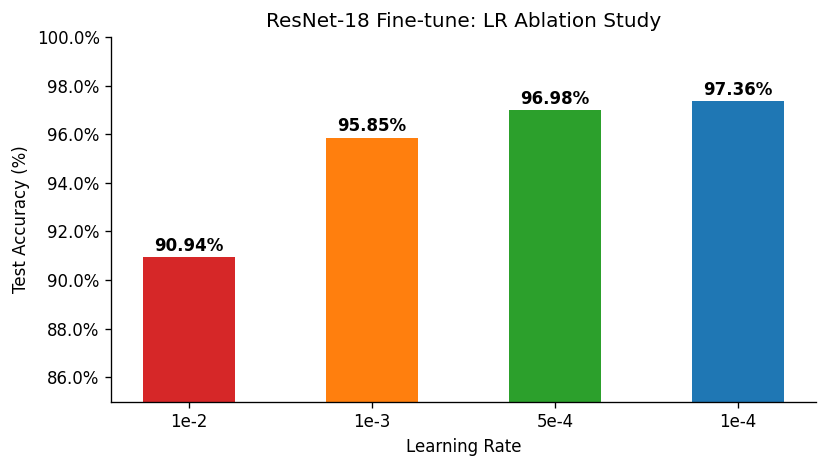

Best learning rate: 1e-4 → 97.36% test accuracy
Higher LR causes catastrophic forgetting of pretrained weights.


In [7]:
# LR ablation results (from test_results.json files)
lr_labels  = ['1e-2', '1e-3', '5e-4', '1e-4']
lr_values  = [1e-2, 1e-3, 5e-4, 1e-4]
lr_acc     = [90.94, 95.85, 96.98, 97.36]
colors     = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(lr_labels, lr_acc, color=colors, width=0.5)
ax.set_ylim(85, 100)
ax.set_xlabel('Learning Rate')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('ResNet-18 Fine-tune: LR Ablation Study')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

for bar, acc in zip(bars, lr_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print('Best learning rate: 1e-4 → 97.36% test accuracy')
print('Higher LR causes catastrophic forgetting of pretrained weights.')

## 7. Training Dynamics of the Best Fine-tuned Model

Let's examine how the best fine-tuned model (`lr=1e-4`, `batch_size=64`) trained over time.

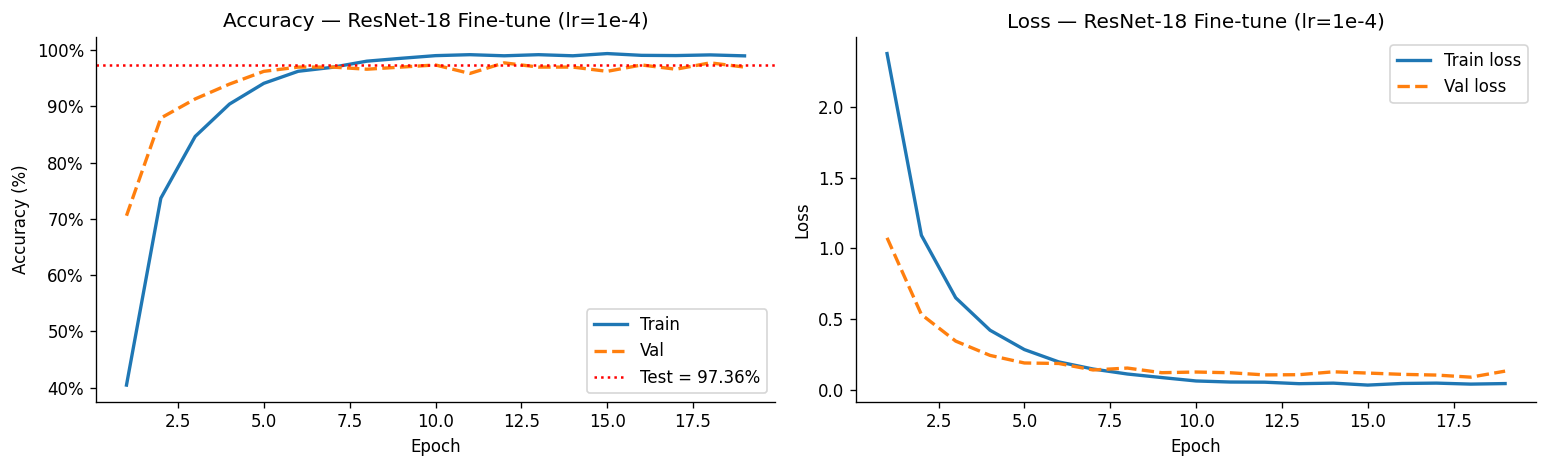

Observations:
  • Fast convergence: >96% val accuracy by epoch 5.
  • Minimal overfitting gap: train and val accuracy stay close throughout.
  • Val loss bottoms out around epoch 18 — early stopping captures the best checkpoint.
  • 19 epochs total (max=30, early stopping with patience=10).


In [8]:
# Training history from runs/resnet18_finetune_lr0.0001_bs64_ep30_20260309_165454/results.csv
# 19 epochs — early stopping triggered (patience=10, but val_acc plateaued around epoch 12-18)
ft_epochs    = list(range(1, 20))
ft_train_acc = [0.404643,0.736752,0.846537,0.904119,0.940976,0.962356,0.969439,0.980325,
                0.985441,0.990163,0.991868,0.9899,0.991868,0.9899,0.993835,0.990687,
                0.990294,0.991474,0.989769]
ft_val_acc   = [0.70566,0.879245,0.913208,0.939623,0.962264,0.969811,0.969811,0.966038,
                0.969811,0.973585,0.958491,0.977358,0.969811,0.969811,0.962264,0.973585,
                0.966038,0.977358,0.969811]
ft_train_loss= [2.379465,1.092818,0.650236,0.420571,0.283598,0.19624,0.145889,0.110583,
                0.08546,0.061309,0.053758,0.052669,0.042041,0.045942,0.03212,0.043657,
                0.046094,0.039101,0.042902]
ft_val_loss  = [1.07509,0.531979,0.343412,0.242366,0.18863,0.185221,0.139219,0.152677,
                0.119884,0.124611,0.119392,0.104244,0.105754,0.126238,0.117252,0.10821,
                0.103105,0.08825,0.130991]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Accuracy
ax1.plot(ft_epochs, [v*100 for v in ft_train_acc], label='Train', lw=2)
ax1.plot(ft_epochs, [v*100 for v in ft_val_acc],   label='Val',   lw=2, ls='--')
ax1.axhline(97.36, color='red', ls=':', lw=1.5, label='Test = 97.36%')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Accuracy — ResNet-18 Fine-tune (lr=1e-4)')
ax1.legend(); ax1.yaxis.set_major_formatter(mtick.PercentFormatter())

# Loss
ax2.plot(ft_epochs, ft_train_loss, label='Train loss', lw=2)
ax2.plot(ft_epochs, ft_val_loss,   label='Val loss',   lw=2, ls='--')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.set_title('Loss — ResNet-18 Fine-tune (lr=1e-4)')
ax2.legend()

plt.tight_layout()
plt.show()

print('Observations:')
print('  • Fast convergence: >96% val accuracy by epoch 5.')
print('  • Minimal overfitting gap: train and val accuracy stay close throughout.')
print('  • Val loss bottoms out around epoch 18 — early stopping captures the best checkpoint.')
print('  • 19 epochs total (max=30, early stopping with patience=10).')

The fine-tuned model reaches **97.36% test accuracy** — but we can do slightly better.

## 8. Best Solution: Fine-tuned Features + SVM

### The Idea

Once the ResNet-18 backbone has been **fine-tuned on card images**, the 512-dimensional feature vectors it produces are no longer generic ImageNet features — they're domain-adapted card representations. These vectors encode the discriminative visual patterns for cards: suit shapes, rank symbols, corner layouts.

At this point, the classification problem becomes **nearly linearly separable**. An SVM with an RBF kernel is a strong choice for this regime:
- **Fewer parameters** than the neural classification head → less overfitting on the small 265-sample test set.
- The **margin maximization** objective of SVM is well-suited for high-dimensional, well-separated features.
- **No gradient descent needed** — fits directly from the extracted features.

### Feature extractor code

In [9]:
import torch

class ResNet18FinetunedFeatures(nn.Module):
    """
    Loads a fine-tuned ResNet18 checkpoint, removes the classification head,
    and returns 512-dim feature vectors for sklearn classifiers.
    """
    def __init__(self, checkpoint_path: str, num_classes: int = 53):
        super().__init__()
        backbone = models.resnet18(weights=None)
        backbone.fc = nn.Linear(backbone.fc.in_features, num_classes)

        # Load fine-tuned weights
        state = torch.load(checkpoint_path, map_location='cpu')
        state = {k.removeprefix('model.'): v for k, v in state.items()}
        backbone.load_state_dict(state)

        # Remove classifier head — output is now raw 512-dim embeddings
        backbone.fc = nn.Identity()
        for param in backbone.parameters():
            param.requires_grad = False
        self.model = backbone

    def forward(self, x):
        return self.model(x)   # (B, 512)


print('ResNet18FinetunedFeatures: outputs 512-dim vectors from a domain-adapted backbone.')

ResNet18FinetunedFeatures: outputs 512-dim vectors from a domain-adapted backbone.


### Sklearn trainer code

In [10]:
from sklearn.svm import SVC
import numpy as np

# SVM configuration
clf = SVC(kernel='rbf', C=10, gamma='scale', probability=True)

# Training flow (pseudo-code — actual training ran separately):
#
#   feature_extractor = ResNet18FinetunedFeatures(checkpoint_path)
#   X_train, y_train = extract_all_features(train_loader, feature_extractor)
#   X_test,  y_test  = extract_all_features(test_loader,  feature_extractor)
#
#   clf.fit(X_train, y_train)        # SVM fits on 7,624 × 512 matrix
#   test_acc = clf.score(X_test, y_test)

print('SVM configuration: RBF kernel, C=10, gamma=scale')
print()
print('Result (from runs/resnet18_finetuned_sklearn_svm_*/test_results.json):')
result = {'acc': 0.977358, 'prec': 0.982031, 'rec': 0.977358, 'f1': 0.977416}
for k, v in result.items():
    print(f'  {k:>6}: {v*100:.2f}%')

SVM configuration: RBF kernel, C=10, gamma=scale

Result (from runs/resnet18_finetuned_sklearn_svm_*/test_results.json):
     acc: 97.74%
    prec: 98.20%
     rec: 97.74%
      f1: 97.74%


## 9. Backbone Quality: The Real Bottleneck

To make the backbone quality argument concrete, let's compare SVMs trained on two different feature sets:
1. **ImageNet features** — raw frozen ResNet-18 (never seen cards)
2. **Fine-tuned features** — ResNet-18 adapted to cards

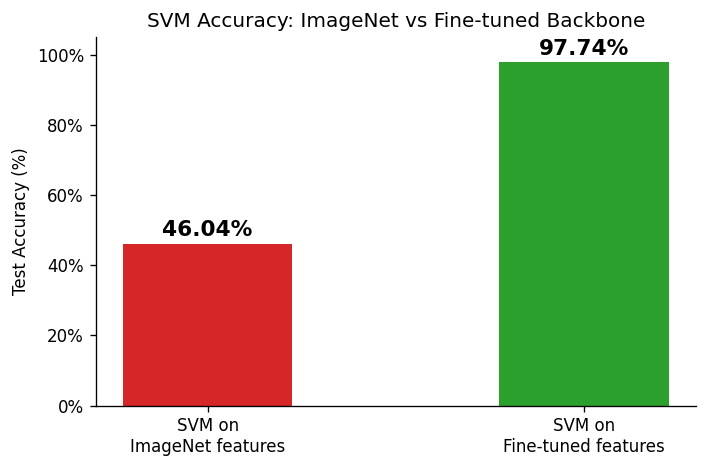

Same classifier (SVM, same hyperparameters).
Switching the backbone from ImageNet to fine-tuned: +51.70 percentage points.

Conclusion: the backbone IS the bottleneck. Once features are right,
almost any classifier achieves good performance.


In [11]:
# Results from test_results.json files
backbone_labels = ['SVM on\nImageNet features', 'SVM on\nFine-tuned features']
backbone_acc    = [46.04, 97.74]
backbone_colors = ['#d62728', '#2ca02c']

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(backbone_labels, backbone_acc, color=backbone_colors, width=0.45)
ax.set_ylim(0, 105)
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('SVM Accuracy: ImageNet vs Fine-tuned Backbone')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())

for bar, acc in zip(bars, backbone_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc:.2f}%', ha='center', va='bottom', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print('Same classifier (SVM, same hyperparameters).')
print('Switching the backbone from ImageNet to fine-tuned: +51.70 percentage points.')
print()
print('Conclusion: the backbone IS the bottleneck. Once features are right,')
print('almost any classifier achieves good performance.')

## 10. Ensemble Experiments

We also explored stacking ensembles combining the fine-tuned neural network, SVM, and RandomForest (all using fine-tuned features).

Results:

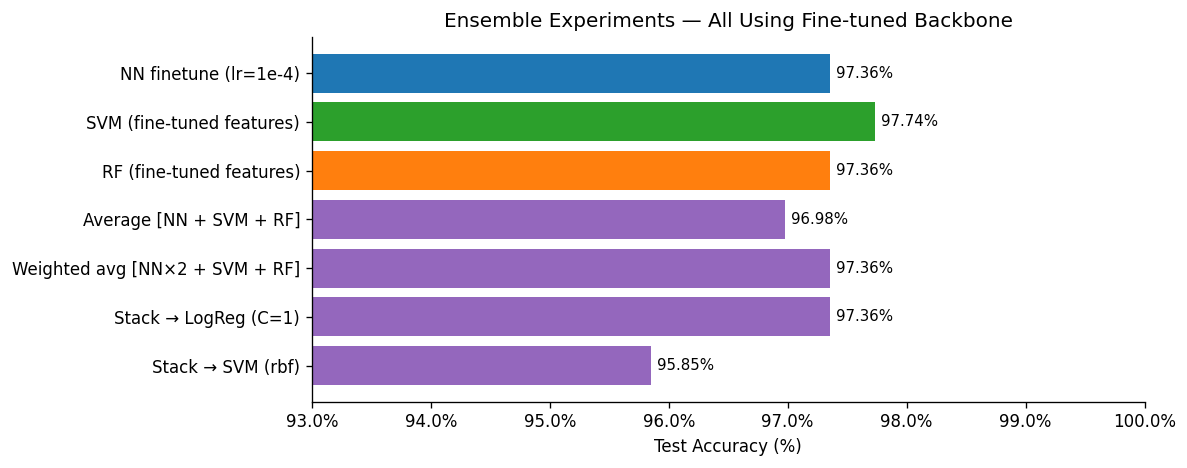

Key finding: ensembles do NOT consistently outperform the best single model (SVM).

Why? All three models share the same fine-tuned backbone.
When they make mistakes, they tend to make the SAME mistakes.
Ensemble gains require diverse base models — diversity is missing here.


In [12]:
# Results from runs/ensemble_stacking/ensemble_results.json
ensemble_results = {
    'NN finetune (lr=1e-4)':          {'acc': 0.973585, 'f1': 0.973318},
    'SVM (fine-tuned features)':      {'acc': 0.977358, 'f1': 0.977416},
    'RF (fine-tuned features)':       {'acc': 0.973585, 'f1': 0.973318},
    'Average [NN + SVM + RF]':        {'acc': 0.969811, 'f1': 0.969506},
    'Weighted avg [NN×2 + SVM + RF]': {'acc': 0.973585, 'f1': 0.973318},
    'Stack → LogReg (C=1)':           {'acc': 0.973585, 'f1': 0.973318},
    'Stack → SVM (rbf)':              {'acc': 0.958491, 'f1': 0.959149},
}

names = list(ensemble_results.keys())
accs  = [v['acc'] * 100 for v in ensemble_results.values()]

fig, ax = plt.subplots(figsize=(10, 4))
bar_colors = ['#1f77b4', '#2ca02c', '#ff7f0e'] + ['#9467bd'] * 4
bars = ax.barh(names[::-1], accs[::-1], color=bar_colors[::-1])
ax.set_xlim(93, 100)
ax.set_xlabel('Test Accuracy (%)')
ax.set_title('Ensemble Experiments — All Using Fine-tuned Backbone')
ax.xaxis.set_major_formatter(mtick.PercentFormatter())

for bar, acc in zip(bars, accs[::-1]):
    ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
            f'{acc:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print('Key finding: ensembles do NOT consistently outperform the best single model (SVM).')
print()
print('Why? All three models share the same fine-tuned backbone.')
print('When they make mistakes, they tend to make the SAME mistakes.')
print('Ensemble gains require diverse base models — diversity is missing here.')

## 11. Full Results Summary

In [13]:
summary = [
    ('CustomCNN (from scratch)',          70.57, 70.12),
    ('ResNet-18 frozen + MLP',            52.83, 51.36),
    ('ResNet-18 fine-tune (lr=1e-2)',     90.94, 90.77),
    ('ResNet-18 fine-tune (lr=1e-3)',     95.85, 95.74),
    ('ResNet-18 fine-tune (lr=5e-4)',     96.98, 96.95),
    ('ResNet-18 fine-tune (lr=1e-4)',     97.36, 97.33),
    ('SVM on ImageNet features',          46.04, 45.74),
    ('SVM on fine-tuned features ★',     97.74, 97.74),
]

df = pd.DataFrame(summary, columns=['Model', 'Test Acc (%)', 'Test F1 (%)'])
df = df.sort_values('Test Acc (%)', ascending=False).reset_index(drop=True)

# Highlight best row
def highlight_best(s):
    is_max = s == s.max()
    return ['background-color: #d4edda; font-weight: bold' if v else '' for v in is_max]

df.style.apply(highlight_best, subset=['Test Acc (%)'])

,Model,Test Acc (%),Test F1 (%)
0,SVM on fine-tuned features ★,97.740000,97.740000
1,ResNet-18 fine-tune (lr=1e-4),97.360000,97.330000
2,ResNet-18 fine-tune (lr=5e-4),96.980000,96.950000
3,ResNet-18 fine-tune (lr=1e-3),95.850000,95.740000
4,ResNet-18 fine-tune (lr=1e-2),90.940000,90.770000
5,CustomCNN (from scratch),70.570000,70.120000
6,ResNet-18 frozen + MLP,52.830000,51.360000
7,SVM on ImageNet features,46.040000,45.740000


## 12. Key Takeaways

### 1. Full fine-tuning beats frozen transfer learning for specialized domains
Frozen ImageNet features are useless for playing cards. The domain gap is too large. Full fine-tuning lets the backbone adapt its representations to the new domain — this is the single most impactful change in the entire experiment.

### 2. Learning rate is critical for fine-tuning
Using `lr=1e-4` instead of `lr=1e-2` improved accuracy by **+6.4 percentage points**. A large LR destroys the pretrained weights (*catastrophic forgetting*) before the network adapts. Fine-tuning pretrained ResNets: `1e-4` to `5e-4` is the sweet spot.

### 3. A good backbone makes the classifier almost irrelevant
Once the backbone is domain-adapted, SVM and the neural head perform nearly identically (~97%). The feature extraction quality is the bottleneck — not which classifier sits on top.

### 4. SVM on fine-tuned features beats the end-to-end network
The SVM achieves **97.74%** vs the neural net's **97.36%** on the same backbone. With a small test set (265 samples), fewer parameters is an advantage. The margin-maximizing SVM objective generalizes better than the softmax head trained with cross-entropy.

### 5. Ensembles require diverse base models
When all models share the same backbone, their errors are correlated. Ensembles only improve over the best single model when base models make *different* mistakes. Here they don't — so ensembles don't help.

---

**Final architecture:** ResNet-18 (fully fine-tuned, `lr=1e-4`, 19 epochs) → strip classifier → 512-dim features → SVM (RBF, `C=10`) → **97.74% test accuracy**